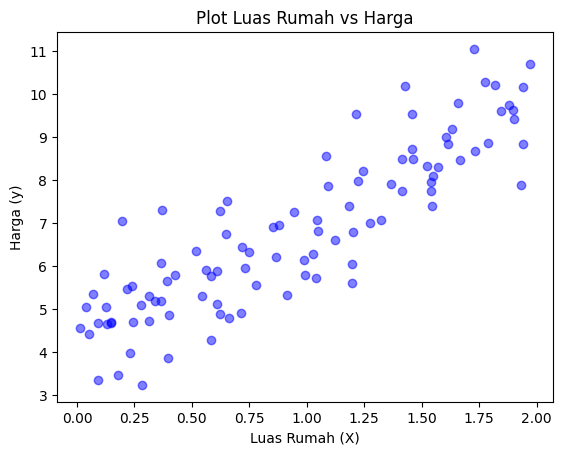

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
# 1. Membuat data dummy (contoh: Luas Rumah vs Harga)
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # Luas rumah (X)
y = 4 + 3 * X + np.random.randn(100, 1) # Harga (y) dengan noise
# Visualisasi Data
plt.scatter(X, y, color='blue', alpha=0.5)
plt.title('Plot Luas Rumah vs Harga')
plt.xlabel('Luas Rumah (X)')
plt.ylabel('Harga (y)')
plt.show()

In [6]:
# Membagi data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")


Jumlah data latih: 80
Jumlah data uji: 20


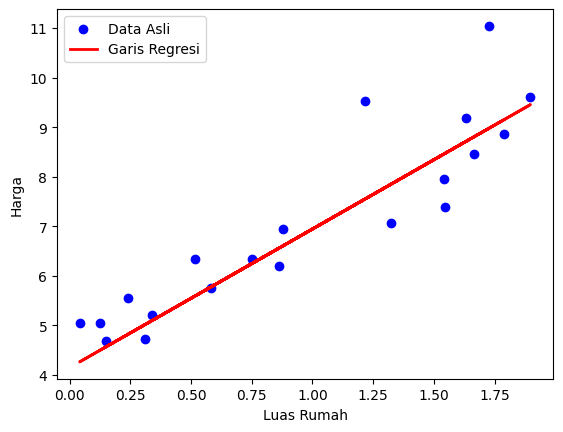

In [7]:
# Inisialisasi model
model_regresi = LinearRegression()
# Melatih model menggunakan data latih
model_regresi.fit(X_train, y_train)
# Membuat prediksi menggunakan data uji
y_pred = model_regresi.predict(X_test)
# Memvisualisasikan Garis Regresi
plt.scatter(X_test, y_test, color='blue', label='Data Asli')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Garis Regresi')
plt.xlabel('Luas Rumah')
plt.ylabel('Harga')
plt.legend()
plt.show()

In [11]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
# Memuat data
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target # 0: Malignant (Ganas), 1: Benign (Jinak)
print(f"Dimensi fitur: {X.shape}")
print("Nama fitur contoh:", cancer_data.feature_names[:3])

Dimensi fitur: (569, 30)
Nama fitur contoh: ['mean radius' 'mean texture' 'mean perimeter']


In [13]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Inisialisasi dan Latih Model Klasifikasi
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
# Prediksi
y_pred_class = rf_model.predict(X_test)

Akurasi Model: 0.9707602339181286
              precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        63
      benign       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



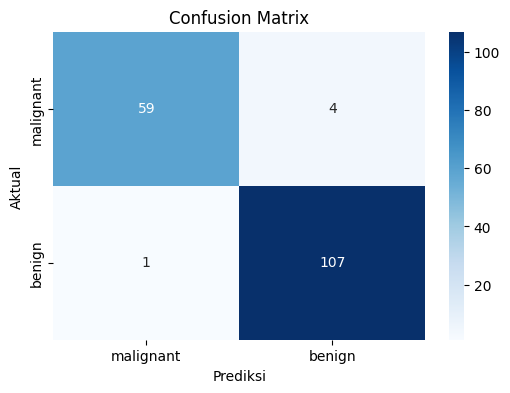

In [17]:
# Akurasi Umum
print("Akurasi Model:", accuracy_score(y_test, y_pred_class))
# Menampilkan Laporan Lengkap (Presisi, Recall, F1-Score)
print(classification_report(y_test, y_pred_class, target_names=cancer_data.target_names))
# Visualisasi Confusion Matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=cancer_data.target_names,
yticklabels=cancer_data.target_names)

plt.title('Confusion Matrix')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

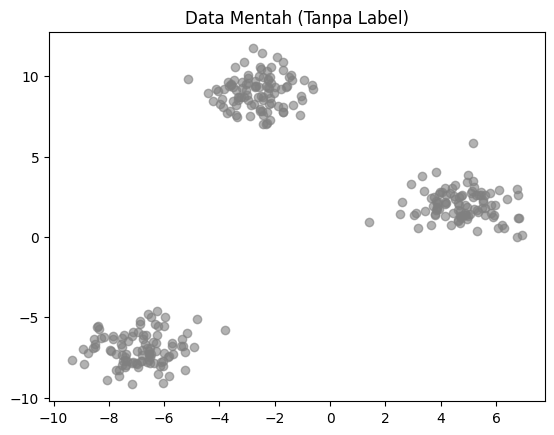

In [19]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
# Membuat data acak tanpa label (3 kelompok tersembunyi)
X_cluster, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
# Plot data awal (belum dikelompokkan)
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], color='gray', alpha=0.6)
plt.title("Data Mentah (Tanpa Label)")
plt.show()

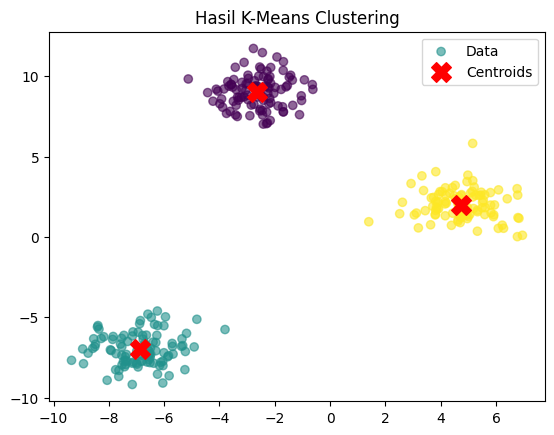

In [20]:
# Inisialisasi model K-Means untuk mencari 3 kelompok (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_cluster)
# Mendapatkan hasil prediksi kelompok
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
# Plot Hasil Clustering
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=labels, cmap='viridis', alpha=0.6, label='Data')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("Hasil K-Means Clustering")
plt.legend()
plt.show()